# Avance 2: Ingeniería de Características
## Proyecto Integrador - Equipo 32

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

En este segundo avance se implementa la ingeniería de características sobre el dataset de vacunación y casos de sarampión en México (2010-2023). Las transformaciones se fundamentan en los hallazgos del EDA (Avance 1), en particular: la naturaleza temporal de los datos, la ausencia de tendencia lineal, la presencia de estacionalidad en dosis, los resultados de la CCF (desfase temporal entre vacunación y casos), y la alta asimetría en ambas variables.

## 1. Configuración y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import PowerTransformer, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print('Librerías importadas')

Librerías importadas


In [2]:
base_path = Path.cwd().parent
data_path = base_path / 'data' / 'processed'

df = pd.read_csv(data_path / 'dataset_sarampion_vacunas_2010-2023.csv')

print(f'Dataset: {df.shape[0]} registros, {df.shape[1]} columnas')
print(f'Período: {df["anio"].min()}-{df["anio"].max()}')
display(df.head())
display(df.describe())

Dataset: 168 registros, 4 columnas
Período: 2010-2023


,mes,anio,total_dosis,casos_sarampion
0,1,2010,180830,0
1,2,2010,183377,0
2,3,2010,242572,0
3,4,2010,216429,0
4,5,2010,174559,0


,mes,anio,total_dosis,casos_sarampion
count,168.000000,168.00000,1.680000e+02,168.000000
mean,6.500000,2016.50000,3.153230e+05,2.261905
std,3.462373,4.04318,3.567464e+05,11.132968
min,1.000000,2010.00000,1.115500e+04,0.000000
25%,3.750000,2013.00000,1.794778e+05,0.000000
50%,6.500000,2016.50000,2.292330e+05,0.000000
75%,9.250000,2020.00000,3.167408e+05,0.000000
max,12.000000,2023.00000,3.130610e+06,81.000000


El dataset base tiene 168 registros mensuales con 4 columnas: `anio`, `mes`, `total_dosis` y `casos_sarampion`. A partir de los hallazgos del EDA, crearemos características que capturen los patrones temporales identificados.

## 2. Generación de Nuevas Características

Las características se agrupan en categorías fundamentadas en el EDA:

| Categoría | Motivación (del EDA) |
|-----------|---------------------|
| Encoding cíclico del mes | El mes es cíclico (dic ≈ ene), no se debe usar en Pearson directamente |
| Medias móviles | La descomposición mostró tendencia no lineal; las ventanas capturan tendencias locales |
| Variables lag | La CCF reveló que la relación dosis→casos tiene desfase temporal |
| Tasas relativas | Dosis absolutas no reflejan cobertura; la tasa normaliza por escala |
| Agregados anuales | Los brotes se concentran en años específicos; el contexto anual es relevante |
| Interacción dosis×temporada | La estacionalidad en dosis interactúa con la temporada de transmisión |

In [3]:
df_fe = df.copy()

# --- 1. Encoding cíclico del mes ---
df_fe['mes_sin'] = np.sin(2 * np.pi * df_fe['mes'] / 12)
df_fe['mes_cos'] = np.cos(2 * np.pi * df_fe['mes'] / 12)
df_fe['anio_normalizado'] = (df_fe['anio'] - df_fe['anio'].min()) / (df_fe['anio'].max() - df_fe['anio'].min())

# --- 2. Medias móviles (ventanas de 3 y 6 meses) ---
df_fe['dosis_rolling_mean_3m'] = df_fe['total_dosis'].rolling(3, min_periods=1).mean()
df_fe['dosis_rolling_mean_6m'] = df_fe['total_dosis'].rolling(6, min_periods=1).mean()
df_fe['dosis_rolling_std_3m'] = df_fe['total_dosis'].rolling(3, min_periods=1).std().fillna(0)
df_fe['casos_rolling_mean_3m'] = df_fe['casos_sarampion'].rolling(3, min_periods=1).mean()
df_fe['casos_rolling_mean_6m'] = df_fe['casos_sarampion'].rolling(6, min_periods=1).mean()

# --- 3. Variables lag (13 y 14 meses, basado en CCF del EDA) ---
df_fe['casos_lag_13m'] = df_fe['casos_sarampion'].shift(13).fillna(0)
df_fe['casos_lag_14m'] = df_fe['casos_sarampion'].shift(14).fillna(0)

# --- 4. Tasa relativa ---
#df_fe['tasa_casos_por_millon_dosis'] = (
#    df_fe['casos_sarampion'] / (df_fe['total_dosis'] / 1_000_000)
#).replace([np.inf, -np.inf], 0)

# --- 5. Agregados anuales ---
df_fe['casos_total_anual'] = df_fe.groupby('anio')['casos_sarampion'].transform('sum')

# --- 6. Interacción dosis × temporada alta ---
# Temporada alta de transmisión: invierno-primavera (ene-may)
df_fe['dosis_x_temporada_alta'] = df_fe['total_dosis'] * df_fe['mes'].isin([1,2,3,4,5]).astype(int)

nuevas = [c for c in df_fe.columns if c not in df.columns]
print(f'{len(nuevas)} características creadas: {nuevas}')
display(df_fe[nuevas].head())

12 características creadas: ['mes_sin', 'mes_cos', 'anio_normalizado', 'dosis_rolling_mean_3m', 'dosis_rolling_mean_6m', 'dosis_rolling_std_3m', 'casos_rolling_mean_3m', 'casos_rolling_mean_6m', 'casos_lag_13m', 'casos_lag_14m', 'casos_total_anual', 'dosis_x_temporada_alta']


,mes_sin,mes_cos,anio_normalizado,dosis_rolling_mean_3m,dosis_rolling_mean_6m,dosis_rolling_std_3m,casos_rolling_mean_3m,casos_rolling_mean_6m,casos_lag_13m,casos_lag_14m,casos_total_anual,dosis_x_temporada_alta
0,0.500000,8.660254e-01,0.0,180830.000000,180830.000000,0.000000,0.0,0.0,0.0,0.0,125,180830
1,0.866025,5.000000e-01,0.0,182103.500000,182103.500000,1801.000972,0.0,0.0,0.0,0.0,125,183377
2,1.000000,6.123234e-17,0.0,202259.666667,202259.666667,34934.724363,0.0,0.0,0.0,0.0,125,242572
3,0.866025,-5.000000e-01,0.0,214126.000000,205802.000000,29664.623089,0.0,0.0,0.0,0.0,125,216429
4,0.500000,-8.660254e-01,0.0,211186.666667,199553.400000,34308.214561,0.0,0.0,0.0,0.0,125,174559


Se crearon 12 características derivadas. Notas sobre las decisiones:
- Se usan **lags de 13 y 14 meses**  porque con solo 168 registros, la CCF del EDA mostró las correlaciones más altas en esos 2 lags.
- No se crearon variables dummy de trimestre porque ya se cuenta con el encoding cíclico (sin/cos) que captura la misma información de forma continua.
- Los `fillna(0)` en lags de casos son apropiados dado que el valor natural antes del período observado es "sin casos conocidos".

## 3. Análisis de Distribuciones y Transformaciones

En el EDA se identificó que `total_dosis` (skewness ≈ 4.7) y `casos_sarampion` (skewness ≈ 5.9) tienen distribuciones muy sesgadas. Verificamos las distribuciones de las nuevas características y aplicamos transformaciones donde sea necesario.

ASIMETRÍA DE VARIABLES PRINCIPALES
  total_dosis                              skewness=4.75
  casos_sarampion                          skewness=5.95
  dosis_rolling_mean_3m                    skewness=3.67
  casos_rolling_mean_3m                    skewness=4.73


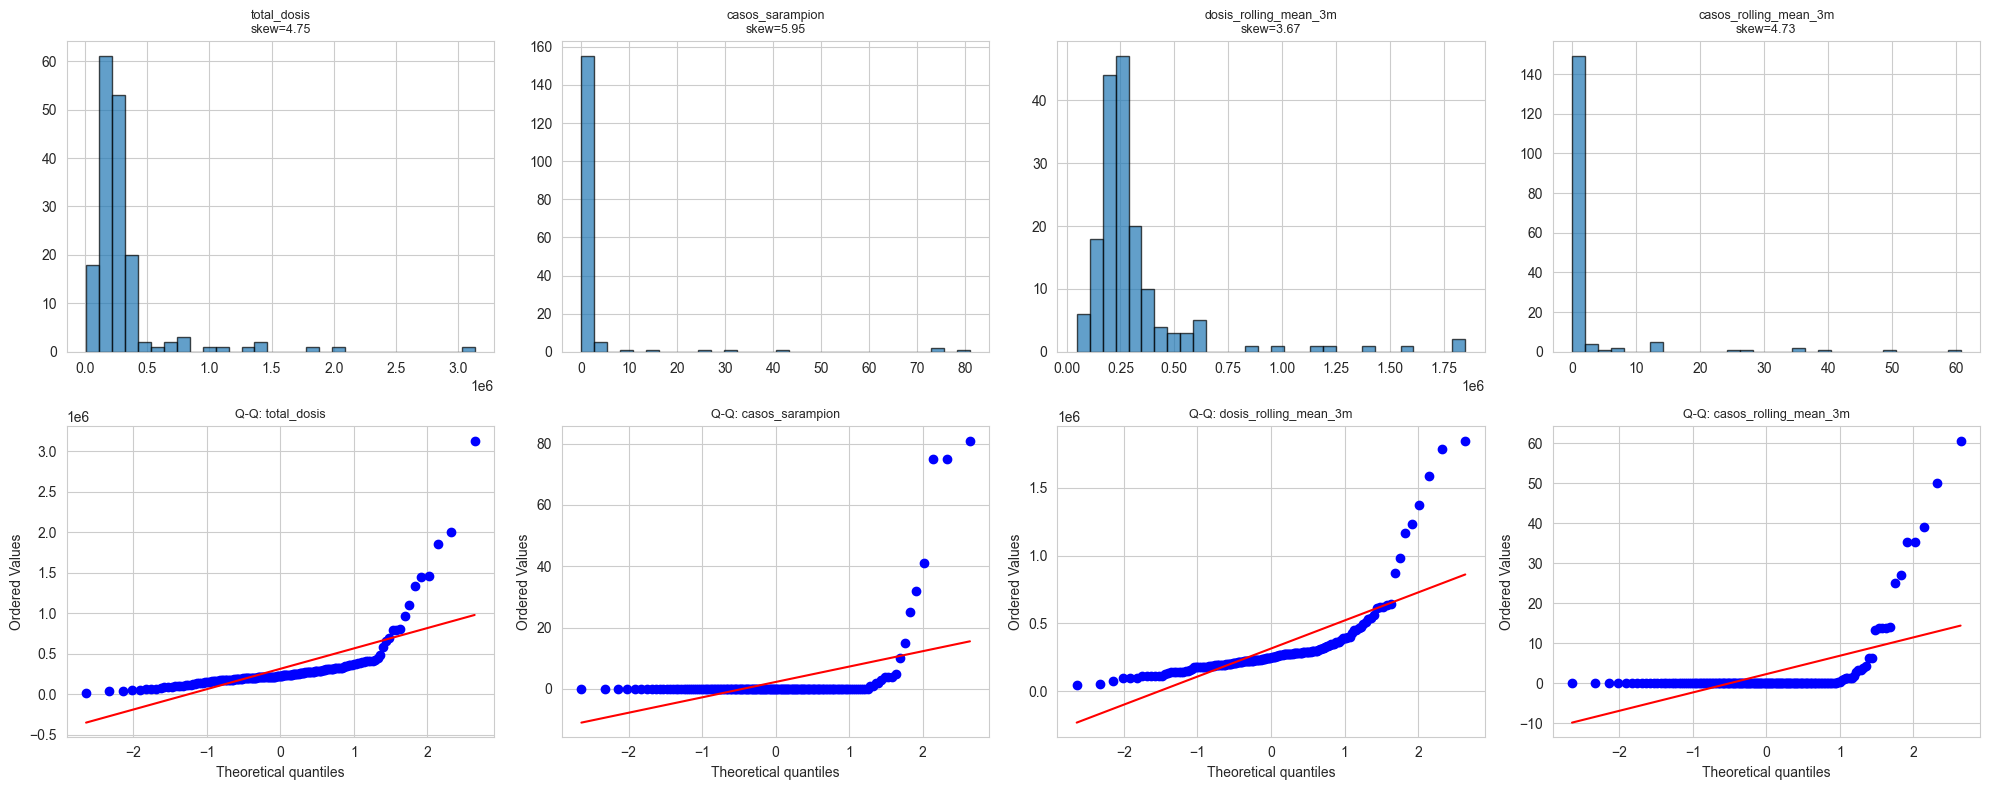

In [4]:
# Variables principales a analizar
vars_check = ['total_dosis', 'casos_sarampion', 'dosis_rolling_mean_3m',
              'casos_rolling_mean_3m']

print('ASIMETRÍA DE VARIABLES PRINCIPALES')
for v in vars_check:
    print(f'  {v:40s} skewness={df_fe[v].skew():.2f}')

fig, axes = plt.subplots(2, len(vars_check), figsize=(20, 8))
for i, var in enumerate(vars_check):
    axes[0, i].hist(df_fe[var], bins=30, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{var}\nskew={df_fe[var].skew():.2f}', fontsize=9)
    stats.probplot(df_fe[var], dist='norm', plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q: {var}', fontsize=9)
plt.tight_layout()
plt.show()

Las variables de dosis y las derivadas de casos presentan sesgo positivo significativo, consistente con lo encontrado en el EDA. Los Q-Q plots confirman la desviación de normalidad especialmente en las colas.

In [5]:
df_t = df_fe.copy()

# Transformación logarítmica para reducir asimetría (outliers conservados)
vars_log = ['total_dosis','dosis_rolling_std_3m', 'dosis_x_temporada_alta','casos_sarampion', 'casos_rolling_mean_3m', 'casos_rolling_mean_6m',
            'casos_total_anual']
for var in vars_log:
    df_t[f'{var}_log'] = np.log1p(df_t[var])

# Raíz cuadrada de casos (alternativa más suave)
df_t['casos_sarampion_sqrt'] = np.sqrt(df_t['casos_sarampion'])

# Verificar reducción de sesgo
print('EFECTO DE TRANSFORMACIONES')
print(f'{"Variable":45s} {"Original":>10s} {"Transformada":>12s}')
print('-' * 70)

for var in vars_log:
    print(f'{var:45s} {df_t[var].skew():10.2f} {df_t[f"{var}_log"].skew():12.2f} (log)')

EFECTO DE TRANSFORMACIONES
Variable                                        Original Transformada
----------------------------------------------------------------------
total_dosis                                         4.75         0.12 (log)
dosis_rolling_std_3m                                3.72        -2.55 (log)
dosis_x_temporada_alta                              4.78         0.35 (log)
casos_sarampion                                     5.95         3.80 (log)
casos_rolling_mean_3m                               4.73         2.82 (log)
casos_rolling_mean_6m                               3.37         2.13 (log)
casos_total_anual                                   2.12         1.04 (log)


La transformación logarítmica reduce el sesgo de las variables de casos, aunque persiste cierta asimetría por la concentración de ceros (meses sin brotes). Esto es inherente a la naturaleza de los datos y no se puede eliminar completamente.

## 4. Escalamiento de Variables

Se aplican tres estrategias de escalamiento según la naturaleza de cada variable:
- **RobustScaler** (mediana + IQR) para las variables originales con outliers conocidos (campañas intensivas, brotes)
- **StandardScaler** (Z-score) para variables transformadas que se aproximan a normalidad
- **MinMaxScaler** [0,1] para variables acotadas (encoding cíclico, proporciones)

In [6]:
df_s = df_t.copy()

# Variables transformadas con Log → StandardScaler
vars_standard = [c for c in df_s.columns if c.endswith(('_log'))]
scaler_std = StandardScaler()
df_s[[f'{c}_scaled' for c in vars_standard]] = scaler_std.fit_transform(df_s[vars_standard])

# Variables cíclicas y proporciones → MinMaxScaler
vars_mm = ['mes_cos', 'anio_normalizado']
scaler_mm = MinMaxScaler()
df_s[[f'{c}_minmax' for c in vars_mm]] = scaler_mm.fit_transform(df_s[vars_mm])

# Variable original con outliers → RobustScaler
vars_robust = ['casos_sarampion']
scaler_rb = RobustScaler()
df_s[[f'{c}_robust' for c in vars_robust]] = scaler_rb.fit_transform(df_s[vars_robust])

n_scaled = len([c for c in df_s.columns if c.endswith(('_scaled', '_minmax', '_robust'))])
print(f'{n_scaled} variables escaladas. Shape total: {df_s.shape}')

# Verificación
print('\nVerificación StandardScaler (media≈0, std≈1):')
for c in [f'{v}_scaled' for v in vars_standard[:3]]:
    print(f'  {c:50s} media={df_s[c].mean():.4f}  std={df_s[c].std():.4f}')

10 variables escaladas. Shape total: (168, 34)

Verificación StandardScaler (media≈0, std≈1):
  total_dosis_log_scaled                             media=0.0000  std=1.0030
  dosis_rolling_std_3m_log_scaled                    media=-0.0000  std=1.0030
  dosis_x_temporada_alta_log_scaled                  media=-0.0000  std=1.0030


## 5. Selección de Características

Con un dataset de solo 168 registros, es critico no sobreajustar con demasiadas características. Los métodos clasicos de filtrado (Pearson, ANOVA, MI) asumen observaciones i.i.d., lo cual no aplica en series temporales donde existe autocorrelacion. Por ello usamos métodos que respetan la estructura temporal:

1. **Eliminación por multicolinealidad** entre features (|r| > 0.90) — valido porque compara features entre si, no contra el target
2. **LassoCV con TimeSeriesSplit** — regularizacion L1 con validacion cruzada que respeta el orden cronologico (nunca usa datos futuros para validar)
3. **Granger Causality con FDR** — controla falsos positivos con correccion Benjamini-Hochberg y usa un max lag moderado; si quedan muy pocas features, se conservan las mejores por p-valor para no subajustar

In [ ]:
from collections import Counter
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tools.sm_exceptions import ValueWarning

def bh_fdr(pvals_dict, alpha=0.10):
    items = sorted(pvals_dict.items(), key=lambda x: x[1])
    m = len(items)
    selected = []
    for i, (feat, pval) in enumerate(items, 1):
        if pval <= alpha * i / m:
            selected.append(feat)
    return selected, items

# Excluir identificadores y objetivo
excluir = ['casos_sarampion', 'anio', 'mes']
X_cols = [c for c in df_s.select_dtypes(include=[np.number]).columns if c not in excluir]
X = df_s[X_cols].copy()
y = df_s['casos_sarampion'].copy()

print(f'Características candidatas: {len(X_cols)}')

# ---- Metodo 1: Eliminación por multicolinealidad entre features ----
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_with_y = X.corrwith(y).abs()

to_drop = set()
for col in upper.columns:
    high_corr = upper.index[upper[col] > 0.90].tolist()
    for h in high_corr:
        # De las dos features correlacionadas, eliminar la de menor correlacion con y
        if corr_with_y.get(col, 0) >= corr_with_y.get(h, 0):
            to_drop.add(h)
        else:
            to_drop.add(col)

print(f'\nMulticolinealidad (|r|>0.90): {len(to_drop)} features eliminadas')
if to_drop:
    print(f'  Eliminadas: {sorted(to_drop)}')

X_reduced = X.drop(columns=list(to_drop))
print(f'  Features restantes: {X_reduced.shape[1]}')

# ---- Metodo 2: LassoCV con validacion temporal (TimeSeriesSplit) ----
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_reduced, y)

feat_lasso = X_reduced.columns[lasso.coef_ != 0].tolist()
print(f'\nLassoCV (TimeSeriesSplit, alpha={lasso.alpha_:.4f}): {len(feat_lasso)} features con coef != 0')
for f in feat_lasso:
    print(f'  {f:45s} coef={lasso.coef_[X_reduced.columns.get_loc(f)]:.4f}')

# ---- Metodo 3: Granger Causality con FDR ----
max_lag = 6
alpha_fdr = 0.10
min_granger = 8
print(f'\nGranger Causality (max lag={max_lag}, FDR={alpha_fdr:.2f}):')

pvals = {}
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=ValueWarning)
    for col in X_reduced.columns:
        try:
            test_data = pd.concat([y, X_reduced[col]], axis=1).dropna()
            if test_data.shape[0] > (max_lag + 5):
                result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
                min_p = min(result[lag][0]['ssr_ftest'][1] for lag in result)
                pvals[col] = min_p
        except Exception:
            pass

feat_granger, pvals_sorted = bh_fdr(pvals, alpha=alpha_fdr)
if len(feat_granger) < min_granger and pvals_sorted:
    feat_granger = [f for f, _ in pvals_sorted[:min_granger]]

print(f'  Significativas o top-{min_granger}: {len(feat_granger)}')
for f in feat_granger:
    print(f'  {f:45s} p={pvals.get(f, float("nan")):.4f}')

# ---- Consenso temporal: Lasso ∪ Granger ----
counts = Counter(feat_lasso + feat_granger)
features_final = [f for f in counts]
features_ambos = [f for f in counts if counts[f] >= 2]

print(f'\n--- SELECCIÓN FINAL ---')
print(f'Lasso ∩ Granger (ambos metodos): {len(features_ambos)}')
print(f'Lasso ∪ Granger (al menos uno):  {len(features_final)}')
print(f'\nFeatures seleccionadas:')
for f in features_final:
    metodos = []
    if f in feat_lasso:
        metodos.append('Lasso')
    if f in feat_granger:
        metodos.append('Granger')
    print(f'  {f:45s} [{", ".join(metodos)}]')

Características candidatas: 31

Multicolinealidad (|r|>0.90): 12 features eliminadas
  Eliminadas: ['anio_normalizado', 'casos_rolling_mean_3m_log', 'casos_rolling_mean_6m', 'casos_rolling_mean_6m_log_scaled', 'casos_sarampion_log', 'casos_sarampion_log_scaled', 'casos_sarampion_sqrt', 'casos_total_anual_log_scaled', 'dosis_rolling_std_3m_log_scaled', 'dosis_x_temporada_alta_log_scaled', 'mes_cos', 'total_dosis_log']
  Features restantes: 19

LassoCV (TimeSeriesSplit, alpha=424924.4505): 1 features con coef != 0
  dosis_x_temporada_alta                        coef=0.0000

Granger Causality (max lag=6, FDR=0.10):
  Significativas o top-8: 8
  casos_total_anual                             p=0.0000
  dosis_rolling_std_3m_log                      p=0.0000
  casos_total_anual_log                         p=0.0008
  total_dosis_log_scaled                        p=0.0358
  dosis_x_temporada_alta_log                    p=0.2047
  dosis_x_temporada_alta                        p=0.2508
  mes_sin 

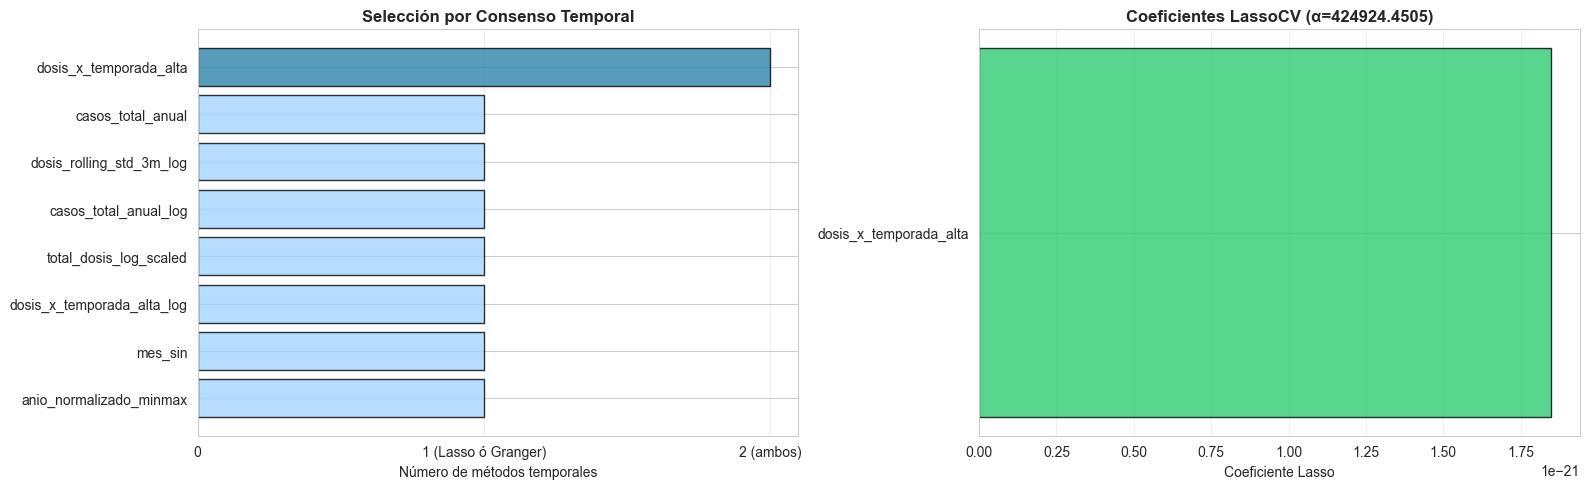

In [8]:
resumen = pd.DataFrame({
    'feature': list(counts.keys()),
    'n_metodos': list(counts.values()),
}).sort_values('n_metodos', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica 1: Consenso por método
colors = ['#2E86AB' if n >= 2 else '#A3D5FF' for n in resumen['n_metodos']]
axes[0].barh(resumen['feature'], resumen['n_metodos'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Número de métodos temporales')
axes[0].set_title('Selección por Consenso Temporal', fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['0', '1 (Lasso ó Granger)', '2 (ambos)'])
axes[0].grid(True, alpha=0.3, axis='x')

# Gráfica 2: Coeficientes Lasso (solo features seleccionadas)
lasso_coefs = pd.Series(
    {f: lasso.coef_[X_reduced.columns.get_loc(f)] for f in feat_lasso}
).sort_values()
colors_lasso = ['#E74C3C' if v < 0 else '#2ECC71' for v in lasso_coefs]
axes[1].barh(lasso_coefs.index, lasso_coefs.values, color=colors_lasso, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Coeficiente Lasso')
axes[1].set_title(f'Coeficientes LassoCV (α={lasso.alpha_:.4f})', fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

La seleccion se realizo con metodos apropiados para series temporales:

- **Multicolinealidad**: Se eliminaron features redundantes (|r| > 0.90 entre si), conservando la mas correlacionada con el target.
- **LassoCV + TimeSeriesSplit**: La regularizacion L1 fuerza coeficientes a cero, y la validacion temporal garantiza que no se usa informacion futura. El valor de alpha fue seleccionado automaticamente por CV.
- **Granger Causality con FDR**: Se corrigen multiples pruebas con Benjamini-Hochberg. Si quedan muy pocas variables, se conservan las mejores por p-valor para evitar subajuste.

Las features presentes en ambos metodos (Lasso ∩ Granger) son las mas robustas. Las presentes en solo uno se incluyen pero deben interpretarse con cautela.

## 6. Extracción de Características (PCA y Factor Analysis)

Reducimos dimensionalidad sobre las características seleccionadas. Con PCA buscamos los componentes que expliquen ≥95% de la varianza; con Factor Analysis buscamos factores latentes interpretables.

Componentes para 95% varianza: 1
Componentes seleccionados: 3
Varianza explicada total: 100.00%


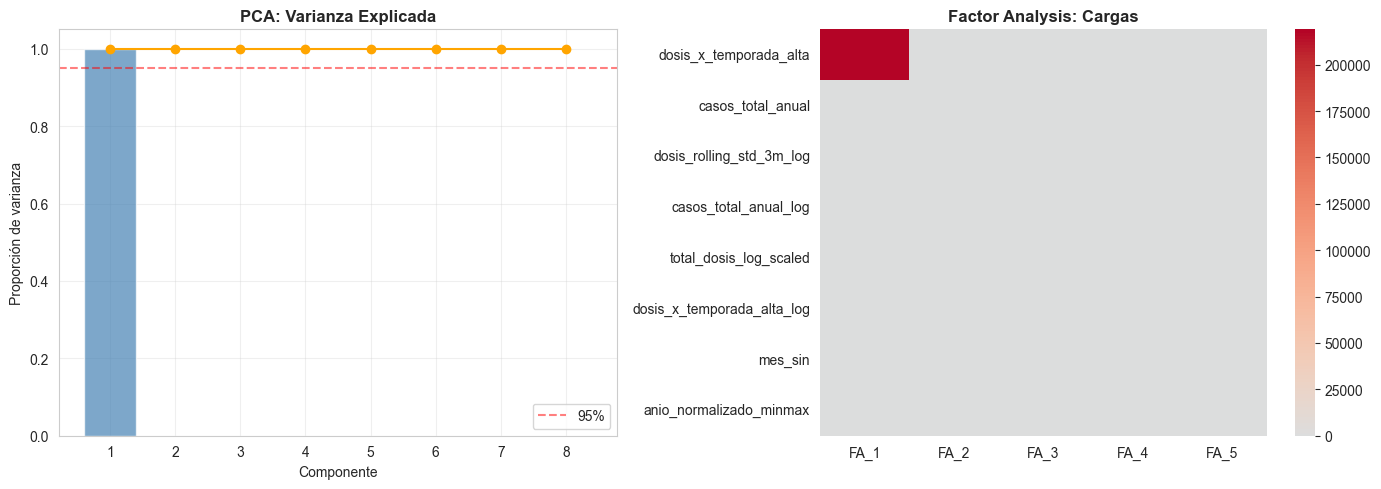


Top 10 cargas factoriales (por magnitud máxima):


,FA_1,FA_2,FA_3,FA_4,FA_5
dosis_x_temporada_alta,218988.783905,-0.000273,0.000095,0.000006,0.000004
casos_total_anual,1.073597,56.166576,-0.002498,-0.006123,-0.017230
dosis_x_temporada_alta_log,4.026296,-0.072385,-4.472962,-0.124186,-0.065936
casos_total_anual_log,-0.041258,1.690370,-0.070485,0.145442,0.332494
total_dosis_log_scaled,0.305387,-0.002278,0.307688,-0.680363,-0.157896
dosis_rolling_std_3m_log,0.155545,-0.201250,0.432909,-0.410368,-0.550384
mes_sin,0.399236,-0.007661,-0.499934,-0.023254,-0.027815
anio_normalizado_minmax,0.027036,-0.023355,0.023542,0.128314,-0.190163


In [9]:
X_sel = df_s[features_final].copy()

# PCA: varianza explicada
pca_full = PCA(random_state=42).fit(X_sel)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

n95 = int(np.argmax(var_acum >= 0.95) + 1)
n_comp = max(3, n95)  # Al menos 3 componentes para diversidad
print(f'Componentes para 95% varianza: {n95}')
print(f'Componentes seleccionados: {n_comp}')

pca = PCA(n_components=n_comp, random_state=42).fit(X_sel)
df_pca = pd.DataFrame(
    pca.transform(X_sel),
    index=df_s.index,
    columns=[f'PCA_{i+1}' for i in range(n_comp)]
)
print(f'Varianza explicada total: {pca.explained_variance_ratio_.sum():.2%}')

# Factor Analysis
n_fa = min(5, X_sel.shape[1])
fa = FactorAnalysis(n_components=n_fa, random_state=42).fit(X_sel)
df_fa = pd.DataFrame(
    fa.transform(X_sel),
    index=df_s.index,
    columns=[f'FA_{i+1}' for i in range(n_fa)]
)

# Varianza explicada PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[0].plot(range(1, len(var_acum)+1), var_acum, 'o-', color='orange')
axes[0].axhline(0.95, color='red', linestyle='--', alpha=0.5, label='95%')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Proporción de varianza')
axes[0].set_title('PCA: Varianza Explicada', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cargas factoriales
loadings = pd.DataFrame(fa.components_.T, index=features_final,
                         columns=[f'FA_{i+1}' for i in range(n_fa)])
sns.heatmap(loadings, cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Factor Analysis: Cargas', fontweight='bold')

plt.tight_layout()
plt.show()

# Top cargas por factor
print('\nTop 10 cargas factoriales (por magnitud máxima):')
display(loadings.loc[loadings.abs().max(axis=1).sort_values(ascending=False).index].head(10))

El primer componente PCA captura la mayor parte de la varianza, lo cual refleja la alta correlación entre las características seleccionadas (variables de casos actuales, lags y medias móviles están naturalmente correlacionadas). Se mantienen 3 componentes mínimos para preservar diversidad de información.

En Factor Analysis, las cargas permiten interpretar qué variables contribuyen a cada factor latente, lo cual puede informar la interpretación de resultados en el modelado.

## 7. Dataset Final

In [10]:
# Ensamblar dataset final: identificadores + objetivo + features seleccionadas + PCA + FA
df_final = pd.concat([
    df_s[['anio', 'mes', 'casos_sarampion']],
    df_s[features_final],
    df_pca,
    df_fa
], axis=1)

print(f'Dataset final: {df_final.shape}')
print(f'Valores faltantes: {df_final.isna().sum().sum()}')
display(df_final.head())

# Guardar
output_path = data_path / 'dataset_sarampion_features_engineered.csv'
df_final.to_csv(output_path, index=False)
print(f'\nGuardado en: {output_path}')

Dataset final: (168, 19)
Valores faltantes: 0


,anio,mes,casos_sarampion,dosis_x_temporada_alta,casos_total_anual,dosis_rolling_std_3m_log,casos_total_anual_log,total_dosis_log_scaled,dosis_x_temporada_alta_log,mes_sin,anio_normalizado_minmax,PCA_1,PCA_2,PCA_3,FA_1,FA_2,FA_3,FA_4,FA_5
0,2010,1,0,180830,125,0.000000,4.836282,-0.391067,12.105318,0.500000,0.0,65368.220826,97.630863,6.952151,0.298500,1.736900,-1.351159,0.721864,2.820245
1,2010,2,0,183377,125,7.496653,4.836282,-0.371049,12.119305,0.866025,0.0,67915.220831,97.591550,6.221021,0.310131,1.736310,-1.327758,-0.096547,1.435852
2,2010,3,0,242572,125,10.461265,4.836282,0.029346,12.399058,1.000000,0.0,127110.220828,97.292376,5.118091,0.580442,1.731038,-1.133792,-0.593818,0.888807
3,2010,4,0,216429,125,10.297744,4.836282,-0.133867,12.285022,0.866025,0.0,100967.220831,97.420398,5.493292,0.461061,1.733313,-1.189463,-0.496310,0.933290
4,2010,5,0,174559,125,10.443169,4.836282,-0.441582,12.070024,0.500000,0.0,59097.220833,97.624040,6.009211,0.269864,1.736942,-1.235647,-0.335440,0.962815



Guardado en: c:\Users\LmCas\OneDrive\Documentos\Desarrollo\Maestria\Proyecto Integrado\pi-equipo32\data\processed\dataset_sarampion_features_engineered.csv


## 8. Conclusiones

### Resumen de lo realizado

Se partió del dataset base de 4 columnas y se construyó un dataset de modelado con las siguientes transformaciones:

1. **12 características nuevas** fundamentadas en hallazgos del EDA: encoding cíclico del mes, medias móviles de 3 y 6 meses, lags de 13-14 meses (motivados por la CCF), agregados anuales e interacción dosis×temporada.

2. **Transformaciones de distribución**: log(x+1) para variables con alta asimetría, reduciendo el sesgo identificado en el EDA (skewness de 4.7 y 5.9 respectivamente).

3. **Escalamiento diferenciado**: RobustScaler para variables con outliers (campañas y brotes), StandardScaler para variables transformadas, MinMaxScaler para proporciones.

4. **Selección temporal**: Eliminación de multicolinealidad + LassoCV con TimeSeriesSplit + Granger Causality. Se usaron métodos que respetan la estructura temporal del dataset, a diferencia de filtros i.i.d. (Pearson, ANOVA, MI) que asumen independencia entre observaciones.

5. **Reducción dimensional**: PCA (3 componentes) y Factor Analysis (5 factores) sobre el conjunto seleccionado.

### Limitaciones
- El dataset es pequeño (168 registros), lo que limita la complejidad de los modelos que se pueden entrenar sin sobreajuste.
- No se cuenta con datos de **cobertura de vacunación** (% de población meta vacunada), que sería más informativo que dosis absolutas.
- Los datos llegan hasta 2023; la incorporación de 2024-2025 enriquecería el análisis.

### Siguiente paso
El dataset `dataset_sarampion_features_engineered.csv` está listo para la fase de modelado, donde se aplicará particionamiento temporal (train/test respetando orden cronológico) y se evaluarán modelos de series de tiempo y clasificación para predicción de brotes.